In [1]:
#| hide
# BASED ON
  # Kalman filtering and smoothing_ANNO^V4.ipynb
  # Kalman filtering and smoothing_ANNO^V3.ipynb
  # Kalman filtering and smoothing_ANNO^V2.ipynb
  # Kalman filtering and smoothing_ANNO^V1.ipynb
  # GP regression by SSM.ipynb

# DONE
# v1 starts ------------------------------------------------
# migrated to RxInfer 3.0.0
# brought over my changes from RxInfer v2.16.2
# Use \mathbf for structures
# x_tL1 & w_tL1 with nice subscripts
# v2 starts ------------------------------------------------
# \mathcal{P} & \mathcal{Q} --> \mathbf{P} & \mathbf{Q}
# insert f() & g() functions
  # works with generating data; took out again to rather have same in both places
  # does NOT work inside @model (same as https://learnableloop.ai/posts/WeightVsHeight_BLOG.html)
    # seems to take literal symbols in the code to build FFG, so
      # x[t] ~ MvNormalMeanCovariance(f(A= A, xₜ₋₁= xₜ₋₁) does not work
# generate_data() --> sim_point_data
# for 'system identification' section: x --> v
  # the 'x' here is not associated with state but just a name for one of the signals
  # 'v' will go better with the other signal called 'w'
# s (for sum, in 'system identification' section) --> z
  # need s for state (which still need to be changed)
# v3 starts ------------------------------------------------
# change x --> s (for state)
# add tildes to hidden state
# v4 starts ------------------------------------------------
# switch roles of A & B
# change P matrix to R matrix
# clean up missing data section
# standardize symbols to DeVries
# have fp() & fr() in envir, but not in agent
  # maybe in future can remove fp() & fr() from envir too
      # so that they look more similar
      # however, I need to have fp() & fr() implemented somewhere 
# v5 starts ------------------------------------------------
# split into 3 pars
# clean

# TODO
# insert (modified) CRISP-DM structure
# replace code vars with math symbols
  # makes mapping between literature and code better to enhance understanding
  # make expressions more concise due to reduced wordyness
# replace hardcoded parameters with symbols


In [2]:
versioninfo() ##. Julia version

Julia Version 1.10.0
Commit 3120989f39b (2023-12-25 18:01 UTC)
Build Info:
  Official https://julialang.org/ release
Platform Info:
  OS: Linux (x86_64-linux-gnu)
  CPU: 12 × Intel(R) Core(TM) i7-8700B CPU @ 3.20GHz
  WORD_SIZE: 64
  LIBM: libopenlibm
  LLVM: libLLVM-15.0.7 (ORCJIT, skylake)
  Threads: 1 on 12 virtual cores
Environment:
  JULIA_NUM_THREADS = 


In [3]:
# Activate local environment, see `Project.toml`
import Pkg; Pkg.activate(".."); Pkg.instantiate();

using RxInfer, BenchmarkTools, Random, LinearAlgebra, Plots, LaTeXStrings, Distributions, StableRNGs

  Activating project at `/workspaces/3.0.0_RxInfer.jl/examples`


In [4]:
Pkg.status()

Status `/workspaces/3.0.0_RxInfer.jl/examples/Project.toml`
⌃ [b4ee3484] BayesBase v1.2.1
  [6e4b80f9] BenchmarkTools v1.5.0
  [336ed68f] CSV v0.10.14
⌃ [159f3aea] Cairo v1.0.5
  [a81c6b42] Compose v0.9.5
  [a93c6f00] DataFrames v1.6.1
⌃ [31c24e10] Distributions v0.25.108
⌃ [62312e5e] ExponentialFamily v1.4.1
⌃ [587475ba] Flux v0.14.11
  [38e38edf] GLM v1.9.0
⌅ [b3f8163a] GraphPPL v4.0.2
⌃ [a2cc645c] GraphPlot v0.5.2
  [f526b714] GraphViz v0.2.0
⌃ [86223c79] Graphs v1.9.0
⌃ [34004b35] HypergeometricFunctions v0.3.23
⌃ [7073ff75] IJulia v1.24.2
  [4138dd39] JLD v0.13.5
  [b964fa9f] LaTeXStrings v1.3.1
  [b81a8e73] LatexSVG v0.3.1
⌃ [23fbe1c1] Latexify v0.16.3
  [429524aa] Optim v1.9.4
⌃ [3bd65402] Optimisers v0.2.20
⌃ [3b7a836e] PGFPlots v3.4.4
  [8314cec4] PGFPlotsX v1.6.1
  [d96e819e] Parameters v0.12.3
⌃ [91a5bcdd] Plots v1.40.1
⌃ [92933f4c] ProgressMeter v1.10.0
⌅ [a194aa59] ReactiveMP v4.0.0
  [37e2e3b7] ReverseDiff v1.15.3
⌃ [df971d30] Rocket v1.8.0
⌃ [86711068] RxInfer v3.0.0
  [

# Kalman filtering and smoothing

In the following set of examples the goal is to estimate hidden <u>states</u> of a Dynamical process where all hidden states are Gaussians.

We start our journey with a simple 

- (1) multivariate Linear Gaussian State Space Model (LGSSM), which can be solved analytically. We then solve an 
- (2) identification problem which does not have an analytical solution. Utimately, we show how **RxInfer.jl** can 
- (3) deal with missing observations.

# 3 Handling Missing Data

An interesting case in filtering and smoothing problems is the processing of missing data. It can happen that sometimes your reading devices fail to acquire the data leading to missing observation.

Let us assume that the following model generates the data

$$\begin{aligned}
    {s}_t &\sim \mathcal{N}\left({s}_{t-1}, w\right) \\
    {y}_t &\sim \mathcal{N}\left({s}_{t}, v \right) 
\end{aligned}$$
where $w = 1.0$

with prior ${s}_0 \sim \mathcal{N}({m_{{s}_0}}, {v_{{s}_0}})$. Suppose that our measurement device fails to acquire data from time to time.  In this case, instead of scalar observation $y_t \in \mathcal{R}$ we sometimes will catch `missing` observations.

In [5]:
_μᵥᵥ = 0.0
_σ²ᵥᵥ = 0.1

_μᵥ = 0.0
_σ²ᵥ = 1.0
_T = 250
_missing_indices = 100:125

100:125

## The Generative Process

### Provision function ($f_p$)
The *provision* function, provides another covariate vector. Because this is a *sequential* system, the provision function defines the transition between the previous state and the current state. This special case of the provision function is known as a *transition* function:

$$\tilde{p}_{t} = f_{p}(t) = t$$
$$\tilde{s}_{t} = f_{p}(t) + w = \tilde{p}_{t} + w$$

where

$w \sim \mathcal{N}(\mu_W, \sigma^2_W)$

The `tilde`s indicate that the parameters and variables are hidden and not observed.

In [6]:
## provision function, provides next batch of covariate vectors
## covariate vector here is just a scalar
function fₚ(;T)
    ## tmp = float.(collect(1:N))
    ## return [[i] for i in tmp]
    p̃ₜ = float.(collect(1:T))
    return p̃ₜ
end
myp̃ₜ = fₚ(T=5)

5-element Vector{Float64}:
 1.0
 2.0
 3.0
 4.0
 5.0

### Response function ($f_r$)
The *response* function, provides the response to the covariate vector.
$$\tilde{r}_{t} = f_{r}(\tilde{s}_{t}) = \mathrm{sin}(0.05t)$$
$$y_{t} = f_{r}(\tilde{s}_{t}) + v = \tilde{r}_{t} + v$$
where

$v \sim \mathcal{N}(\mu_V, \sigma^2_V)$

The `tilde`s indicate that the parameters and variables are hidden and not observed.

In [7]:
## response function, provides next batch of responses to covariate vectors
## covariate vector here is just a scalar
function fᵣ(s̃)
    r̃ₜ = sin.(0.05*s̃)
    return r̃ₜ
end
fᵣ(myp̃ₜ)

5-element Vector{Float64}:
 0.04997916927067833
 0.09983341664682815
 0.14943813247359924
 0.19866933079506122
 0.24740395925452294

In [8]:
## Data comes from either a simulation/lab (sim|lab) OR from the field (fld)
## Data are handled either in batches (batch) OR online as individual points (point)
## Batch data accumulates either
    ## along the depth/examples dimension/axis (into the screen/page), OR
        ## typical for supervised & unsupervised learning
    ## along the time dimension/axis (down the screen page)
        ## typical for sequential decision learning (reinforcement learning & active inference)
function sim_batch_data(T; seed=123, μᵥᵥ, σ²ᵥᵥ, μᵥ, σ²ᵥ) ## simulated batch data
    rng = StableRNG(seed)
    p̃ₜ = fₚ(T=T)
    w = rand(Normal(μᵥᵥ, sqrt(σ²ᵥᵥ)), T)
    s̃ₜ = p̃ₜ + w

    r̃ₜ = fᵣ(s̃ₜ)
    v = rand(Normal(μᵥ, sqrt(σ²ᵥ)), T)
    yₜ = r̃ₜ + v

    yₜ_missing    = similar(yₜ, Union{Float64, Missing}, )
    copyto!(yₜ_missing, yₜ)
    for index in _missing_indices
        yₜ_missing[index] = missing
    end
    return p̃ₜ, s̃ₜ, r̃ₜ, yₜ, yₜ_missing
end

sim_batch_data (generic function with 1 method)

In [9]:
_p̃ₜ, _s̃ₜ, _r̃ₜ, _yₜ, _yₜ_missing = sim_batch_data(
    _T; 
    μᵥᵥ=_μᵥᵥ, σ²ᵥᵥ=_σ²ᵥᵥ, 
    μᵥ=_μᵥ, σ²ᵥ=_σ²ᵥ);

In [10]:
_s̃ₜ

250-element Vector{Float64}:
   0.9222725831355799
   1.6154459821925438
   2.859028570086367
   3.684656287725381
   5.458378720072204
   6.067310232109225
   6.677191474040252
   8.042474183552619
   8.911584457430587
  10.314639000291516
   ⋮
 241.2922219720879
 242.8748853927761
 243.42949657881846
 245.1944802915594
 245.68628264897742
 247.18484384654133
 248.48316969046607
 248.74541096810404
 249.94670065230534

In [11]:
_yₜ

250-element Vector{Float64}:
  1.2673566464986605
  0.6229220573099095
 -0.4151788362712422
 -0.9467800032923563
  1.0026549385712458
 -0.7939397312703405
  0.47903896041770194
  1.6239596003260364
 -0.6842829235704335
  2.7253006455036557
  ⋮
  0.8734149799639804
 -1.4155001190720187
 -2.063226105708136
  0.26265757186561783
  1.104798302579909
  0.7009185888967293
 -0.5229402851292533
 -1.3221639119725284
  0.9234433281337806

In [12]:
_s̃ₜ

250-element Vector{Float64}:
   0.9222725831355799
   1.6154459821925438
   2.859028570086367
   3.684656287725381
   5.458378720072204
   6.067310232109225
   6.677191474040252
   8.042474183552619
   8.911584457430587
  10.314639000291516
   ⋮
 241.2922219720879
 242.8748853927761
 243.42949657881846
 245.1944802915594
 245.68628264897742
 247.18484384654133
 248.48316969046607
 248.74541096810404
 249.94670065230534

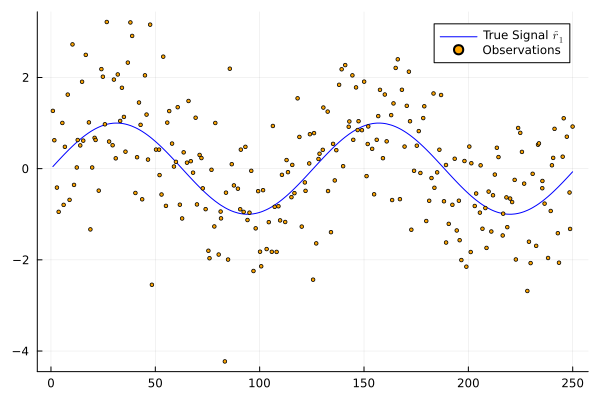

In [13]:
_p = plot()
_p = plot(_p, _s̃ₜ, _r̃ₜ, label="True Signal " * L"\tilde{r}_1", color=:blue)
_p = scatter!(_p, _s̃ₜ, _yₜ, label="Observations", markersize=2, color=:orange)
plot(_p)

## The Generative Model

In [14]:
@model function smoothing(y, s₀)
    v ~ Gamma(shape=0.001, scale=0.001)
    s_prior ~ Normal(mean=mean(s₀), var=var(s₀))
    local s
    sₜ₋₁ = s_prior
    for t in 1:length(y)
        s[t] ~ Normal(mean=sₜ₋₁, precision=1.0)
        y[t] ~ Normal(mean=s[t], precision=v)
        sₜ₋₁ = s[t]
    end
end

In [15]:
_constraints = @constraints begin
    q(s_prior, s, y, v) = q(s_prior, s)q(v)q(y)
end

Constraints: 
  q(s_prior, s, y, v) = q(s_prior, s)q(v)q(y)


In [16]:
_s₀_prior = NormalMeanVariance(0.0, 1000.0)
_initm = @initialization begin
    q(v) = Gamma(0.001, 0.001)
end

_result = infer(
    model = smoothing(s₀=_s₀_prior), 
    data  = (y = _yₜ_missing,), 
    constraints = _constraints,
    initialization = _initm, 
    returnvars = (s = KeepLast(),),
    iterations = 20
);

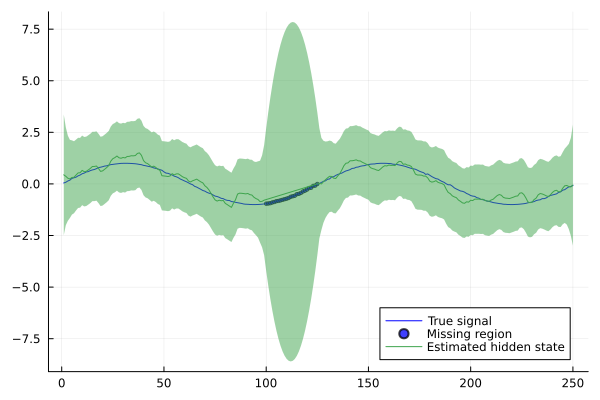

In [17]:
plot(_r̃ₜ, label="True signal", legend=:bottomright, color=:blue)
scatter!(
    _missing_indices, 
    ## _p̃ₜ[_missing_indices], ms=2, opacity=0.75, label="Missing region", color=:blue)
    ## _s̃ₜ[_missing_indices], ms=2, opacity=0.75, label="Missing region", color=:blue)
    _r̃ₜ[_missing_indices], ms=2, opacity=0.75, label="Missing region", color=:blue)
    ## _yₜ[_missing_indices], ms=2, opacity=0.75, label="Missing region", color=:blue)
plot!(
    mean.(_result.posteriors[:s]), 
    ribbon=var.(_result.posteriors[:s]), label="Estimated hidden state")